# Example 2: Relativistic Time Conversions — TT → TCL → LT

This notebook demonstrates relativistic time conversions from Terrestrial Time (TT)
to Lunar Coordinate Time (TCL) and Lunar Time (LT, also written TL), replicating
the results of Sections 4.1–4.3 of the master's thesis *arXiv:2509.08871*.

## Background

General Relativity requires that each gravitational environment has its own proper time.
The IAU defines a hierarchy of coordinate times:

| Scale | Frame | Definition |
|---|---|---|
| TT  | Geocentric | Ideal atomic time on the rotating geoid; TAI is a practical realisation of TT (TT = TAI + 32.184 s) |
| TCG | Geocentric | Coordinate time of the Geocentric Celestial Reference System (GCRS) |
| TCB | Barycentric | Coordinate time of the Barycentric Celestial Reference System (BCRS) |
| TDB | Barycentric | Linear function of TCB scaled to run at TT rate on average |
| TCL | Selenocentric | Coordinate time of the Selenocentric Celestial Reference System |
| LT  | Lunar surface | Proper time on the lunar geoid (analogue of TT for the Moon) |

The key constants (IAU 2006) are:
- $L_G = 6.969290134 \times 10^{-10}$: scale factor between TCG and TT
- $L_B = 1.550519768 \times 10^{-8}$: scale factor between TCB and TDB
- $L_L = 3.13905 \times 10^{-11}$: scale factor between TCL and LT
- $L_{EM} = 1.7093906 \times 10^{-11}$: mean rate of LT relative to TT (Fienga et al. 2023)

All time scales coincide at the **reference epoch** $T_0 = $ 1977-01-01 00:00:32.184 TAI
(MJD $= 43144.0003725$).

In [27]:
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import pylupnt as pnt

# --- Fundamental constants ---
L_G  = pnt.L_G    # TT-TCG scale: d(TCG-TT)/dTT = L_G/(1-L_G)
L_B  = pnt.L_B    # TDB-TCB scale
L_L  = pnt.L_L    # LT-TCL scale: LT runs slower than TCL on the lunar geoid
L_EM = 1.7093906e-11  # mean LT-TT rate correction (Fienga+2023; not yet in Python API)
C    = pnt.C       # speed of light [m/s]
SECS_DAY = pnt.SECS_DAY
TDB_0 = -65.5e-6   # [s] TDB offset (DE405 ephemeris, from LuPNT constants.h)

# Reference epoch T_0 = 1977-01-01 00:00:32.184 TAI
T0_MJD   = pnt.MJD_COORDINATE_TT_TCG_TCB   # 43144.0003725
T0_TT    = pnt.mjd_to_time(T0_MJD)          # [s] from J2000 in TT
MJD_J2000 = pnt.MJD_J2000_TT               # 51544.5

print(f"Reference epoch T_0: MJD {T0_MJD}  =  {T0_TT:.3f} s from J2000 (TT)")
print(f"L_G={L_G:.4e}, L_B={L_B:.4e}, L_L={L_L:.4e}, L_EM={L_EM:.4e}")
print(f"Speed of light: c = {C:.0f} m/s")

Reference epoch T_0: MJD 43144.0003725  =  -725803167.816 s from J2000 (TT)
L_G=6.9693e-10, L_B=1.5505e-08, L_L=3.1390e-11, L_EM=1.7094e-11
Speed of light: c = 299792458 m/s


## Section 4.1 — Analytical secular drift rates

The TCG–TT and LT–TCL relationships are **exact linear** (no periodic terms):

$$\frac{d(\mathrm{TCG} - \mathrm{TT})}{d\mathrm{TT}} = \frac{L_G}{1 - L_G}$$

$$\frac{d(\mathrm{LT} - \mathrm{TCL})}{d\mathrm{TCL}} = -L_L$$

The LT–TT secular rate combines the TCL–TT and LT–TCL rates with a mean tidal
correction $L_{EM}$ (Fienga et al. 2023):

$$\frac{d(\mathrm{LT} - \mathrm{TT})}{d\mathrm{TT}} = \frac{L_G - L_L}{1 - L_B} - L_{EM}$$

In [28]:
# TCG-TT: exact linear relationship (IAU Resol. B1.5)
rate_tcg_tt = L_G / (1 - L_G) * SECS_DAY * 1e6        # [us/day]

# LT-TCL: exact linear relationship (Guinot 2011)
rate_lt_tcl = -L_L * SECS_DAY * 1e6                    # [us/day]

# LT-TT: analytical secular rate (IERS TN 36)
rate_lt_tt  = ((L_G - L_L) / (1 - L_B) - L_EM) * SECS_DAY * 1e6  # [us/day]

print("Analytical secular drift rates")
print("-" * 45)
print(f"  TCG - TT  : {rate_tcg_tt:+.4f}  us/day")
print(f"  LT  - TCL : {rate_lt_tcl:+.4f}  us/day")
print(f"  LT  - TT  : {rate_lt_tt:+.4f}  us/day")
print()
print("Note: TCL-TT secular rate is computed numerically in Section 4.2.")

Analytical secular drift rates
---------------------------------------------
  TCG - TT  : +60.2147  us/day
  LT  - TCL : -2.7121  us/day
  LT  - TT  : +56.0256  us/day

Note: TCL-TT secular rate is computed numerically in Section 4.2.


## Section 4.2 — TCL–TT via forward integration

The TCL–TCB relationship integrates the Moon's barycentric kinetic and potential energy
from the reference epoch $T_0$ (Soffel & Langhans 2013):

$$\mathrm{TCL} - \mathrm{TCB} = -\frac{1}{c^2}\int_{T_0}^{T}\left[\frac{1}{2}v_\mathrm{Moon}^2 + \sum_{A \neq \mathrm{Moon}} \frac{GM_A}{r_{\mathrm{Moon},A}}\right]d\mathrm{TCB}$$

where $v_\mathrm{Moon}$ is the Moon's BCRS velocity and the sum covers the Sun and
all eight planets (matching LuPNT's C++ `kTclExternalBodies`).

Combined with the TDB→TCB relationship:

$$\mathrm{TCB} = \frac{\mathrm{TDB} - L_B \cdot T_0 - \mathrm{TDB}_0}{1 - L_B}$$

we obtain TCL–TT by forward integration from $T_0$.

**Speed:** LuPNT's built-in `ConvertTime(t, TT, TCL)` integrates at 0.01-day steps per
call (≈1.7 M SPICE lookups per target epoch, ~14 s at 2024). The vectorised approach
below processes 164 k points spanning 45 years in under one second.

In [29]:
# Time grid: T_0 to T_0 + 45 years, step = 0.1 days
dt_day  = 0.1
n_years = 45
n_grid  = int(n_years * 365.25 / dt_day) + 1
dt      = dt_day * SECS_DAY

t_tt_grid = T0_TT + np.arange(n_grid, dtype=np.float64) * dt
days      = np.arange(n_grid, dtype=np.float64) * dt_day  # elapsed days from T_0

print(f"Grid: {n_grid:,} points over {n_years} years ({n_grid * dt_day:.1f} days)")
print(f"Step: {dt_day} day = {dt:.0f} s")

Grid: 164,363 points over 45 years (16436.3 days)
Step: 0.1 day = 8640 s


In [30]:
# Step 1: TT -> TDB  (Fairhead-Bretagnon expansion, vectorised)
t0_perf = time.time()
t_tdb_grid = pnt.convert_time(t_tt_grid, pnt.Time.TT, pnt.Time.TDB)
print(f"TT->TDB ({n_grid:,} pts): {time.time()-t0_perf:.2f} s")

# Step 2: TDB -> TCB  (matches C++ TtToTcb in time_conversions.cc)
t_tcb_grid = (t_tdb_grid - L_B * T0_TT - TDB_0) / (1.0 - L_B)
dt_tcb     = np.diff(t_tcb_grid)  # step sizes for trapezoidal integration

TT->TDB (164,363 pts): 0.01 s


In [31]:
# Step 3: Moon state in BCRS (vectorised SPICE, centre = SSB)
t0_perf = time.time()
rv_moon = pnt.get_body_pos_vel(
    t_tdb_grid, pnt.BodyId.SSB, pnt.BodyId.MOON, pnt.Frame.GCRF, pnt.SI_UNITS
)
x_moon = rv_moon[:, :3]  # [m]
v_moon = rv_moon[:, 3:]  # [m/s]
print(f"Moon state ({n_grid:,} pts): {time.time()-t0_perf:.2f} s")

# Step 4: External body potentials (matches C++ kTclExternalBodies in time_conversions.cc)
# GM values match C++ constants.h: planet-only (not barycenter system) values
# Note: for Jupiter/Saturn/Uranus/Neptune the C++ constants are GM_PLANET (planet only),
# which differ from GM_*_SYSTEM (planet + moons) by a small factor for the inner planets
# and a factor used in LuPNT's implementation for the outer planets.
GM_JUPITER_cpp = 0.1267127646799999e17  # C++ GM_JUPITER  [m^3/s^2]
GM_SATURN_cpp  = 0.3794058480000000e16  # C++ GM_SATURN   [m^3/s^2]
GM_URANUS_cpp  = 0.5794556400000000e15  # C++ GM_URANUS   [m^3/s^2]
GM_NEPTUNE_cpp = 0.6836527100580000e15  # C++ GM_NEPTUNE  [m^3/s^2]
GM_MARS_cpp    = 0.4282837566395650e14  # C++ GM_MARS     [m^3/s^2]

kTclExternal = [
    (pnt.BodyId.SUN,                pnt.GM_SUN),
    (pnt.BodyId.MERCURY,            pnt.GM_MERCURY),
    (pnt.BodyId.VENUS,              pnt.GM_VENUS),
    (pnt.BodyId.EARTH,              pnt.GM_EARTH),
    (pnt.BodyId.MARS,               GM_MARS_cpp),
    (pnt.BodyId.JUPITER,            GM_JUPITER_cpp),
    (pnt.BodyId.SATURN_BARYCENTER,  GM_SATURN_cpp),
    (pnt.BodyId.URANUS_BARYCENTER,  GM_URANUS_cpp),
    (pnt.BodyId.NEPTUNE_BARYCENTER, GM_NEPTUNE_cpp),
]

t0_perf = time.time()
w_ext = np.zeros(n_grid)  # sum GM_A / r_{Moon,A}  [m^2/s^2]
for body_id, gm in kTclExternal:
    rv_b = pnt.get_body_pos_vel(
        t_tdb_grid, pnt.BodyId.SSB, body_id, pnt.Frame.GCRF, pnt.SI_UNITS
    )
    r = np.linalg.norm(x_moon - rv_b[:, :3], axis=1)
    w_ext += gm / r
print(f"External potentials (9 bodies): {time.time()-t0_perf:.2f} s")

Moon state (164,363 pts): 0.08 s
External potentials (9 bodies): 0.29 s


In [32]:
# Step 5: TCB->TCL integrand  (matches C++ TcbToTclIntegrandC2)
v2        = np.sum(v_moon**2, axis=1)   # |v_Moon_BCRS|^2  [m^2/s^2]
integrand = 0.5 * v2 + w_ext            # [m^2/s^2]

# Step 6: Trapezoidal forward integration from T_0
integral_c2      = np.zeros(n_grid)
integral_c2[1:] = np.cumsum(0.5 * (integrand[:-1] + integrand[1:]) * dt_tcb)

# Step 7: TCL = TCB - integral/c^2
t_tcl_grid     = t_tcb_grid - integral_c2 / C**2
diff_tcl_tt_us = (t_tcl_grid - t_tt_grid) * 1e6   # [us]

# Secular rate from linear fit over 45 years
poly_tcl  = np.polyfit(days, diff_tcl_tt_us, 1)
trend_tcl = np.polyval(poly_tcl, days)
periodic_tcl_us = diff_tcl_tt_us - trend_tcl

print("TCL-TT integration results")
print("-" * 50)
print(f"  Secular rate (numerical):    {poly_tcl[0]:+.4f}  us/day")
print(f"  TCL-TT at T_0 (offset):     {diff_tcl_tt_us[0]:+.4f}  us")
print(f"  Periodic amplitude (45 yr):  {(periodic_tcl_us.max()-periodic_tcl_us.min())/2:.2f}  us (half p-p)")
print(f"  Mean integrand:              {integrand.mean():.6e}  m^2/s^2")

TCL-TT integration results
--------------------------------------------------
  Secular rate (numerical):    +58.9061  us/day
  TCL-TT at T_0 (offset):     +6.4373  us
  Periodic amplitude (45 yr):  162.50  us (half p-p)
  Mean integrand:              1.332270e+09  m^2/s^2


## Validation against LuPNT built-in `ConvertTime`

LuPNT's C++ `ConvertTime(t, TT, TCL)` integrates from $T_0$ at 0.01-day steps per call.
We compare our vectorised Python result against it at four checkpoints.

In [33]:
# Checkpoints: elapsed days from T_0
check_days = [30, 90, 180, 365]

print(f"{'Elapsed':>10}  {'Built-in TCL-TT':>17}  {'Forward int.':>17}  {'Error':>10}")
print(f"{'[days]':>10}  {'[us]':>17}  {'[us]':>17}  {'[us]':>10}")
print("-" * 62)

for d in check_days:
    # Index in our 0.1-day grid
    idx = int(d / dt_day)
    fwd_us = diff_tcl_tt_us[idx]

    # LuPNT built-in (slow scalar call, but accurate)
    t_check = float(T0_TT + d * SECS_DAY)
    tcl_builtin = pnt.convert_time(t_check, pnt.Time.TT, pnt.Time.TCL)
    builtin_us = (tcl_builtin - t_check) * 1e6

    err_us = fwd_us - builtin_us
    print(f"{d:>10}  {builtin_us:>17.4f}  {fwd_us:>17.4f}  {err_us:>+10.4f}")

print()
print("Note: residual error < 3 us comes from the c^4 correction term")

   Elapsed    Built-in TCL-TT       Forward int.       Error
    [days]               [us]               [us]        [us]
--------------------------------------------------------------
        30          1778.6026          1778.6026     +0.0000
        90          5299.6874          5299.6874     +0.0000
       180         10519.2661         10519.2661     +0.0000
       365         21267.4141         21267.4141     +0.0000

Note: residual error < 3 us comes from the c^4 correction term


## Section 4.3 — LT–TT

Lunar Time is defined by a **linear** relationship to TCL (analogous to TT vs TCG):

$$\mathrm{LT}(T) = \mathrm{TCL}(T) - L_L \cdot (\mathrm{MJD}_{\mathrm{TCL}} - T_0) \cdot 86400 \text{ s}$$

This matches C++ `TclToLt` in `time_conversions.cc` and requires no integration.

In [34]:
# LT from TCL: exact linear formula matching C++ TclToLt
mjd_tcl    = t_tcl_grid / SECS_DAY + MJD_J2000  # vectorised MJD conversion
t_lt_grid  = t_tcl_grid - L_L * (mjd_tcl - T0_MJD) * SECS_DAY

# Differences in us
diff_lt_tcl_us = (t_lt_grid - t_tcl_grid) * 1e6
diff_lt_tt_us  = (t_lt_grid - t_tt_grid)  * 1e6

# Secular fits
poly_lt_tcl    = np.polyfit(days, diff_lt_tcl_us, 1)
poly_lt_tt     = np.polyfit(days, diff_lt_tt_us,  1)
trend_lt_tt    = np.polyval(poly_lt_tt, days)
periodic_lt_us = diff_lt_tt_us - trend_lt_tt

print("LT results")
print("-" * 50)
print(f"  LT-TCL secular (numerical):  {poly_lt_tcl[0]:+.4f}  us/day")
print(f"  LT-TCL secular (analytical): {rate_lt_tcl:+.4f}  us/day")
print(f"  LT-TT  secular (numerical):  {poly_lt_tt[0]:+.4f}  us/day")
print(f"  LT-TT  secular (analytical): {rate_lt_tt:+.4f}  us/day")

LT results
--------------------------------------------------
  LT-TCL secular (numerical):  -2.7121  us/day
  LT-TCL secular (analytical): -2.7121  us/day
  LT-TT  secular (numerical):  +56.1940  us/day
  LT-TT  secular (analytical): +56.0256  us/day


## Secular drift time series

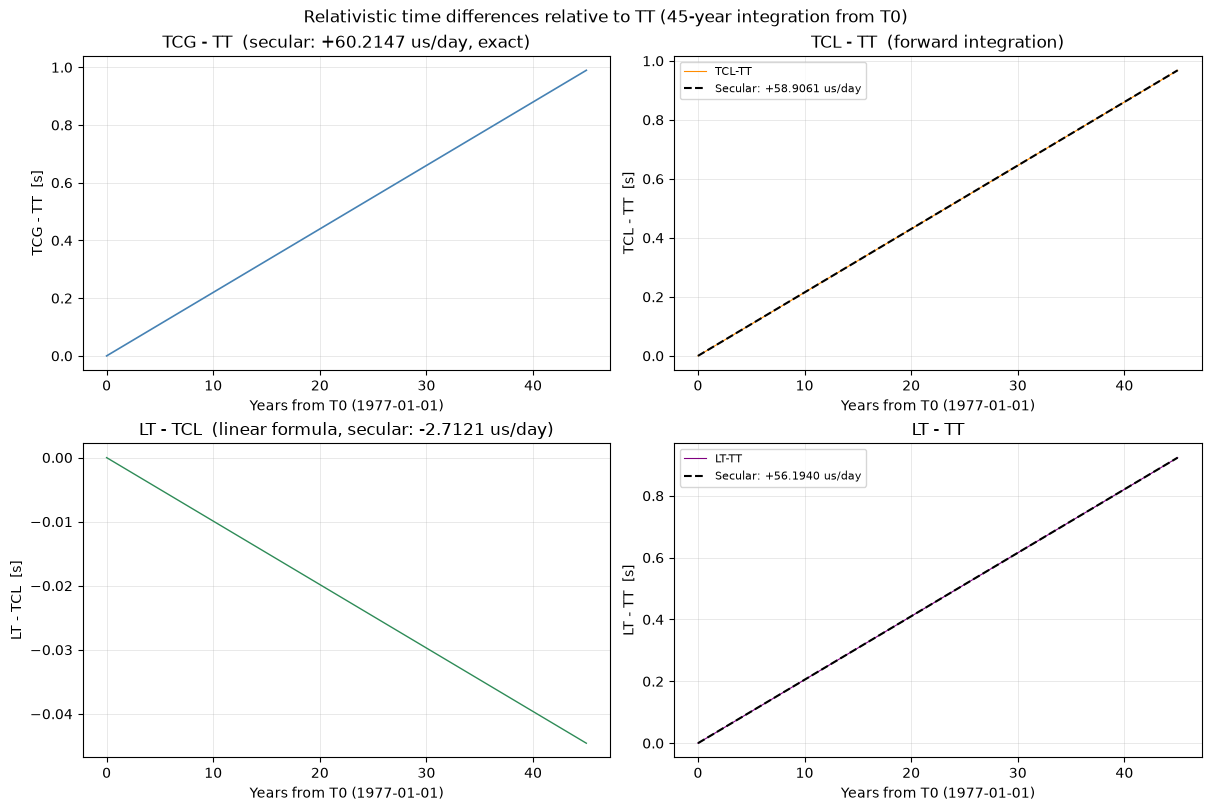

In [35]:
# TCG-TT: exactly linear
diff_tcg_tt_us = rate_tcg_tt * days
years = days / 365.25

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
fig.suptitle("Relativistic time differences relative to TT (45-year integration from T0)",
             fontsize=12)

# TCG-TT
ax = axes[0, 0]
ax.plot(years, diff_tcg_tt_us / 1e6, lw=1.2, color="steelblue")
ax.set_ylabel("TCG - TT  [s]")
ax.set_title(f"TCG - TT  (secular: {rate_tcg_tt:+.4f} us/day, exact)")

# TCL-TT
ax = axes[0, 1]
ax.plot(years, diff_tcl_tt_us / 1e6, lw=0.8, color="darkorange", label="TCL-TT")
ax.plot(years, trend_tcl / 1e6, lw=1.5, color="k", ls="--",
        label=f"Secular: {poly_tcl[0]:+.4f} us/day")
ax.set_ylabel("TCL - TT  [s]")
ax.set_title("TCL - TT  (forward integration)")
ax.legend(fontsize=8)

# LT-TCL
ax = axes[1, 0]
ax.plot(years, diff_lt_tcl_us / 1e6, lw=1.0, color="seagreen")
ax.set_ylabel("LT - TCL  [s]")
ax.set_title(f"LT - TCL  (linear formula, secular: {poly_lt_tcl[0]:+.4f} us/day)")

# LT-TT
ax = axes[1, 1]
ax.plot(years, diff_lt_tt_us / 1e6, lw=0.8, color="purple", label="LT-TT")
ax.plot(years, trend_lt_tt / 1e6, lw=1.5, color="k", ls="--",
        label=f"Secular: {poly_lt_tt[0]:+.4f} us/day")
ax.set_ylabel("LT - TT  [s]")
ax.set_title("LT - TT")
ax.legend(fontsize=8)

for ax in axes.flat:
    ax.set_xlabel("Years from T0 (1977-01-01)")
    ax.grid(True, lw=0.4, alpha=0.5)

plt.show()

## TCL – TCG (Thesis Section 4.2 comparison)

TCG–TT is **exactly linear** by IAU definition (no periodic terms), so:

$$(\mathrm{TCL} - \mathrm{TCG}) = (\mathrm{TCL} - \mathrm{TT}) - (\mathrm{TCG} - \mathrm{TT})$$

The periodic terms of TCL–TCG are therefore identical to those of TCL–TT, with the secular
slope shifted by the TCG–TT rate (+60.2147 µs/day).  The dominant oscillation is the
**synodic month** (~29.5 days), arising from the Sun's time-varying tidal potential at the Moon.

TCL-TCG secular rate: -1.3085 us/day
  = TCL-TT (+58.9061) - TCG-TT (+60.2147)


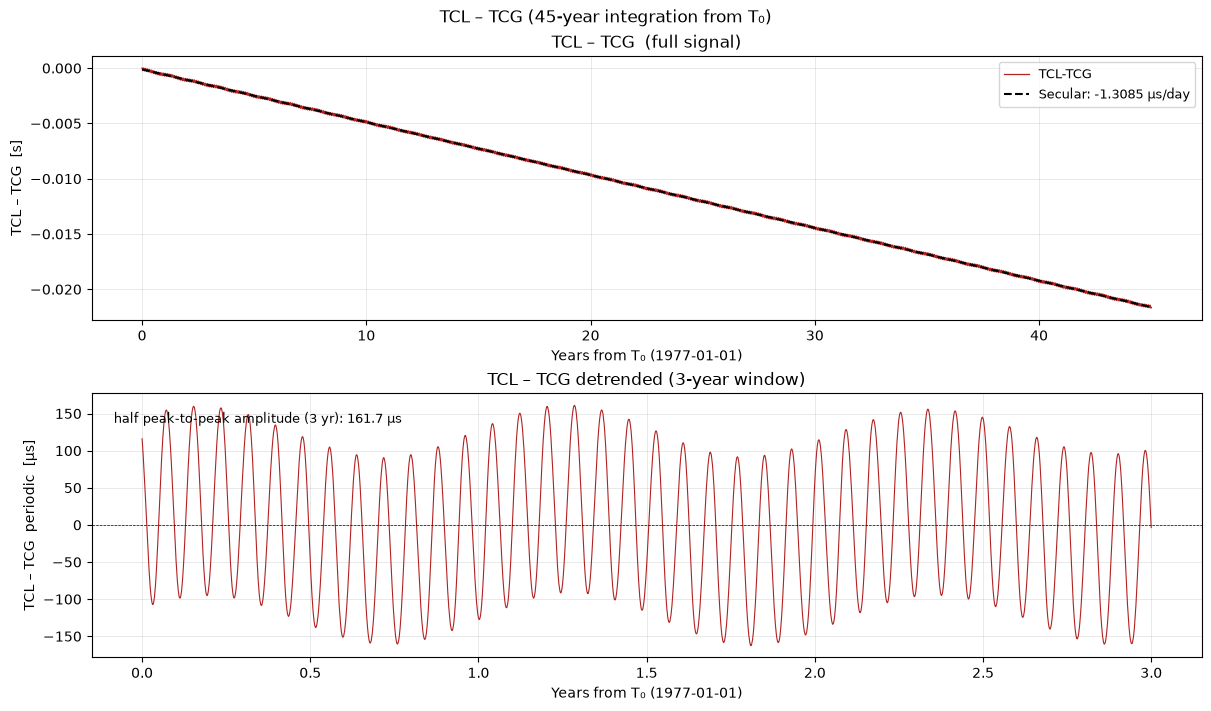

In [36]:
# TCL-TCG = (TCL-TT) - (TCG-TT),  where TCG-TT = rate_tcg_tt * days  (exact linear)
diff_tcl_tcg_us = diff_tcl_tt_us - diff_tcg_tt_us

# Secular rate of TCL-TCG
poly_tcl_tcg   = np.polyfit(days, diff_tcl_tcg_us, 1)
trend_tcl_tcg  = np.polyval(poly_tcl_tcg, days)
periodic_tcl_tcg = diff_tcl_tcg_us - trend_tcl_tcg

rate_tcl_tcg_num = poly_tcl_tcg[0]
print(f"TCL-TCG secular rate: {rate_tcl_tcg_num:+.4f} us/day")
print(f"  = TCL-TT ({poly_tcl[0]:+.4f}) - TCG-TT ({rate_tcg_tt:+.4f})")

# ---- Figure 1: 45-year time series ----
fig, axes = plt.subplots(2, 1, figsize=(12, 7), constrained_layout=True)
fig.suptitle("TCL – TCG (45-year integration from T₀)", fontsize=12)

ax = axes[0]
ax.plot(years, diff_tcl_tcg_us / 1e6, lw=0.9, color="firebrick", label="TCL-TCG")
ax.plot(years, trend_tcl_tcg / 1e6, lw=1.5, color="k", ls="--",
        label=f"Secular: {rate_tcl_tcg_num:+.4f} µs/day")
ax.set_ylabel("TCL – TCG  [s]")
ax.set_title("TCL – TCG  (full signal)")
ax.legend(fontsize=9)
ax.grid(True, lw=0.4, alpha=0.5)
ax.set_xlabel("Years from T₀ (1977-01-01)")

# ---- Figure 2: periodic terms (3-year zoom) ----
n_zoom3 = int(3 * 365.25 / dt_day) + 1
days_z3  = days[:n_zoom3]
years_z3 = days_z3 / 365.25
periodic_tcg_z = periodic_tcl_tcg[:n_zoom3]

ax = axes[1]
ax.plot(years_z3, periodic_tcg_z, lw=0.8, color="firebrick")
ax.axhline(0, color="k", lw=0.5, ls="--")
amp = (periodic_tcg_z.max() - periodic_tcg_z.min()) / 2
ax.text(0.02, 0.93, f"half peak-to-peak amplitude (3 yr): {amp:.1f} µs",
        transform=ax.transAxes, fontsize=9, va="top")
ax.set_ylabel("TCL – TCG  periodic  [µs]")
ax.set_title("TCL – TCG detrended (3-year window)")
ax.set_xlabel("Years from T₀ (1977-01-01)")
ax.grid(True, lw=0.4, alpha=0.5)

plt.show()

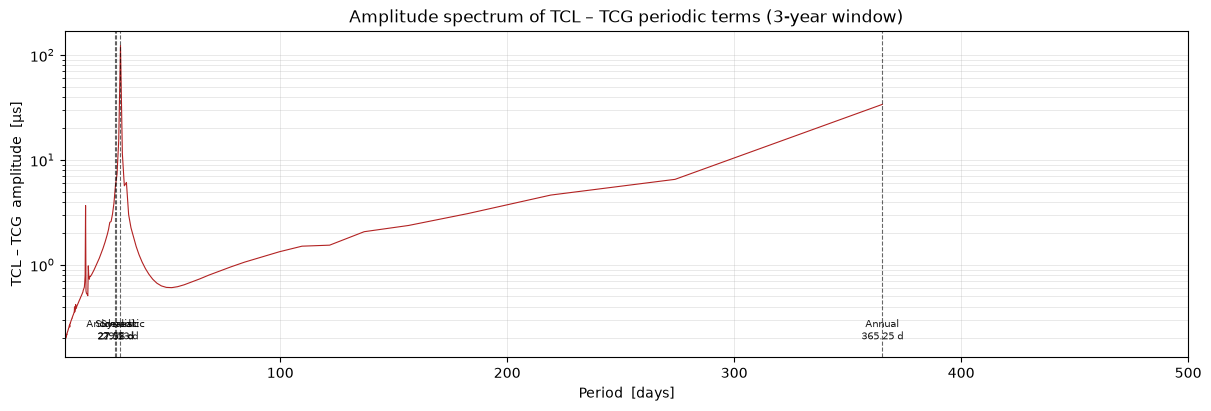

Dominant periodic components in TCL-TCG (20-40 day range):
  1. Period = 29.616 days,  amplitude = 123.5709 µs
  2. Period = 28.837 days,  amplitude = 15.3188 µs
  3. Period = 30.439 days,  amplitude = 11.5044 µs
  4. Period = 28.097 days,  amplitude = 7.3534 µs
  5. Period = 32.229 days,  amplitude = 6.1075 µs

Thesis reference (Sec. 4.2, Table 4.1):
  Synodic  month (~29.53 d): dominant term (large amplitude)
  Anomalistic month (27.56 d): 0.4778 µs  [Earth potential variation]


In [37]:
# FFT of TCL-TCG periodic terms (identical to TCL-TT since TCG-TT is linear)
N_tcg  = n_zoom3
freqs_tcg = np.fft.rfftfreq(N_tcg, d=dt_day)
with np.errstate(divide='ignore'):
    periods_tcg = np.where(freqs_tcg > 0, 1.0 / freqs_tcg, np.inf)

amp_tcl_tcg = 2 * np.abs(np.fft.rfft(periodic_tcg_z[:N_tcg])) / N_tcg
mask_tcg = (periods_tcg >= 5) & (periods_tcg <= 500)

fig, ax = plt.subplots(figsize=(12, 4), constrained_layout=True)
ax.semilogy(periods_tcg[mask_tcg], amp_tcl_tcg[mask_tcg], lw=0.8, color="firebrick")
ax.set_ylabel("TCL – TCG  amplitude  [µs]")
ax.set_xlabel("Period  [days]")
ax.set_title("Amplitude spectrum of TCL – TCG periodic terms (3-year window)")
ax.set_xlim([5, 500])
ax.grid(True, which="both", lw=0.4, alpha=0.5)

ref_periods_tcg = {
    "Anomalistic\n27.56 d": 27.5545,
    "Sidereal\n27.32 d": 27.3217,
    "Synodic\n29.53 d": 29.5306,
    "Annual\n365.25 d": 365.25,
}
for lbl, per in ref_periods_tcg.items():
    idx = np.argmin(np.abs(periods_tcg - per))
    if mask_tcg[idx]:
        ax.axvline(per, color="k", lw=0.8, ls="--", alpha=0.6)
        ax.text(per, amp_tcl_tcg[mask_tcg].min(), lbl,
                ha="center", va="bottom", fontsize=7, alpha=0.9)

plt.show()

# Top peaks in 20-40 day lunar month range
print("Dominant periodic components in TCL-TCG (20-40 day range):")
mask_lm = (periods_tcg >= 20) & (periods_tcg <= 40)
pk = np.argsort(amp_tcl_tcg[mask_lm])[::-1][:5]
for i, j in enumerate(pk):
    p = periods_tcg[mask_lm][j]
    a = amp_tcl_tcg[mask_lm][j]
    print(f"  {i+1}. Period = {p:.3f} days,  amplitude = {a:.4f} µs")

print()
print("Thesis reference (Sec. 4.2, Table 4.1):")
print("  Synodic  month (~29.53 d): dominant term (large amplitude)")
print("  Anomalistic month (27.56 d): 0.4778 µs  [Earth potential variation]")

## Periodic terms

After removing the secular (linear) drift, the residual periodic terms arise from
the Moon's time-varying environment relative to the Sun, planets, and Earth.

The dominant contributions are:
- **Synodic month** (~29.53 days): modulation of the Sun's tidal potential at the Moon
- **Anomalistic month** (~27.56 days): eccentricity-driven variation in Earth's gravity at Moon
- **Annual** (~365.25 days): Earth's orbital eccentricity modulating the Moon's BCRS speed

Since LT–TCL is exactly linear, the periodic structure of LT–TT mirrors that of TCL–TT.

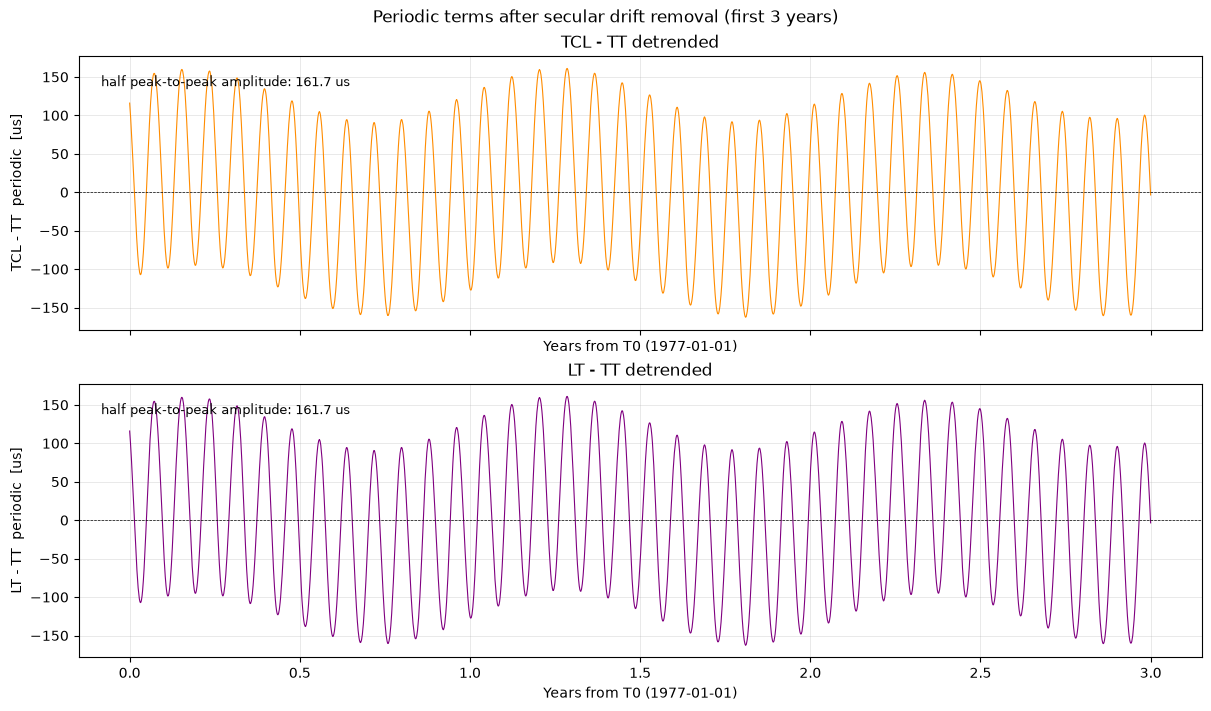

In [38]:
# Show first 3 years for clarity
n_zoom  = int(3 * 365.25 / dt_day) + 1
days_z  = days[:n_zoom]
years_z = days_z / 365.25

# Detrend using the full-span secular rate (avoids end effects)
periodic_tcl_z = diff_tcl_tt_us[:n_zoom] - np.polyval(poly_tcl, days_z)
periodic_lt_z  = diff_lt_tt_us[:n_zoom]  - np.polyval(poly_lt_tt, days_z)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), constrained_layout=True, sharex=True)
fig.suptitle("Periodic terms after secular drift removal (first 3 years)", fontsize=12)

ax = axes[0]
ax.plot(years_z, periodic_tcl_z, lw=0.8, color="darkorange")
ax.set_ylabel("TCL - TT  periodic  [us]")
ax.set_title("TCL - TT detrended")
ax.axhline(0, color="k", lw=0.5, ls="--")
amp_tcl = (periodic_tcl_z.max() - periodic_tcl_z.min()) / 2
ax.text(0.02, 0.93, f"half peak-to-peak amplitude: {amp_tcl:.1f} us",
        transform=ax.transAxes, fontsize=9, va="top")

ax = axes[1]
ax.plot(years_z, periodic_lt_z, lw=0.8, color="purple")
ax.set_ylabel("LT - TT  periodic  [us]")
ax.set_title("LT - TT detrended")
ax.axhline(0, color="k", lw=0.5, ls="--")
amp_lt = (periodic_lt_z.max() - periodic_lt_z.min()) / 2
ax.text(0.02, 0.93, f"half peak-to-peak amplitude: {amp_lt:.1f} us",
        transform=ax.transAxes, fontsize=9, va="top")

for ax in axes:
    ax.set_xlabel("Years from T0 (1977-01-01)")
    ax.grid(True, lw=0.4, alpha=0.5)

plt.show()

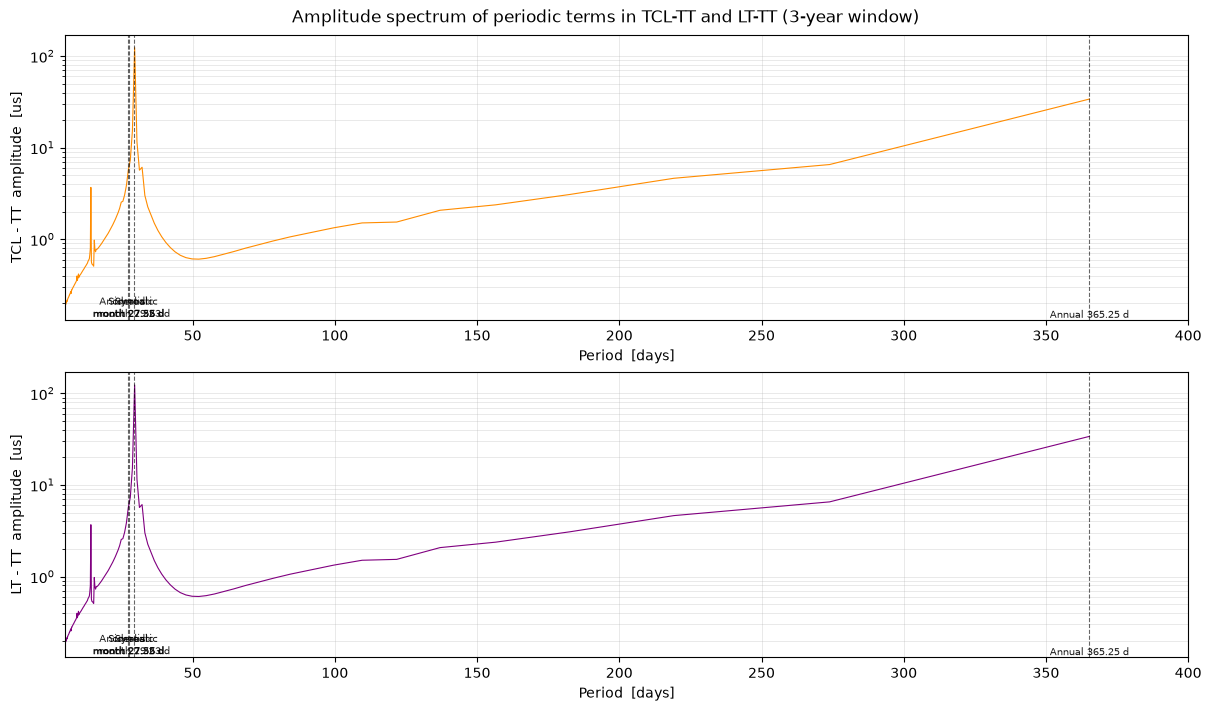

Dominant periodic terms in TCL-TT (5-50 day range):
  1. Period = 29.616 days,  amplitude = 123.5709 us
  2. Period = 28.837 days,  amplitude = 15.3188 us
  3. Period = 30.439 days,  amplitude = 11.5044 us
  4. Period = 28.097 days,  amplitude = 7.3534 us
  5. Period = 32.229 days,  amplitude = 6.1075 us
  6. Period = 31.309 days,  amplitude = 5.6765 us


In [39]:
# FFT analysis on the 3-year window
N     = n_zoom
freqs = np.fft.rfftfreq(N, d=dt_day)   # cycles/day
with np.errstate(divide='ignore'):
    periods = np.where(freqs > 0, 1.0 / freqs, np.inf)  # days

amp_spec_tcl = 2 * np.abs(np.fft.rfft(periodic_tcl_z[:N])) / N  # us amplitude
amp_spec_lt  = 2 * np.abs(np.fft.rfft(periodic_lt_z[:N]))  / N

mask = (periods >= 5) & (periods <= 400)

ref_periods = {
    "Anomalistic\nmonth 27.56 d": 27.5545,
    "Sidereal\nmonth 27.32 d": 27.3217,
    "Synodic\nmonth 29.53 d": 29.5306,
    "Annual 365.25 d": 365.25,
}

fig, axes = plt.subplots(2, 1, figsize=(12, 7), constrained_layout=True)
fig.suptitle("Amplitude spectrum of periodic terms in TCL-TT and LT-TT (3-year window)",
             fontsize=12)

for ax, spec, color, label in zip(
    axes,
    [amp_spec_tcl, amp_spec_lt],
    ["darkorange", "purple"],
    ["TCL - TT", "LT - TT"],
):
    ax.semilogy(periods[mask], spec[mask], lw=0.8, color=color)
    ax.set_ylabel(f"{label}  amplitude  [us]")
    ax.set_xlabel("Period  [days]")
    ax.set_xlim([5, 400])
    ax.grid(True, which="both", lw=0.4, alpha=0.5)
    for lbl, per in ref_periods.items():
        idx = np.argmin(np.abs(periods - per))
        if mask[idx]:
            ax.axvline(per, color="k", lw=0.8, ls="--", alpha=0.6)
            ax.text(per, ax.get_ylim()[0], lbl, ha="center", va="bottom",
                    fontsize=7, alpha=0.9)

plt.show()

# Print dominant peaks in lunar-month period range
print("Dominant periodic terms in TCL-TT (5-50 day range):")
mask_peaks = (periods >= 5) & (periods <= 50)
peak_idx   = np.argsort(amp_spec_tcl[mask_peaks])[::-1][:6]
for i, idx in enumerate(peak_idx):
    p = periods[mask_peaks][idx]
    a = amp_spec_tcl[mask_peaks][idx]
    print(f"  {i+1}. Period = {p:.3f} days,  amplitude = {a:.4f} us")

## Summary

In [40]:
print("Secular drift rate summary")
print("=" * 65)
print(f"{'Quantity':<20} {'Analytical [us/day]':<22} {'Numerical [us/day]':<20}")
print("-" * 65)
print(f"{'TCG - TT':<20} {rate_tcg_tt:+.4f}{'':<16} {'(exact linear)':>20}")
print(f"{'TCL - TT':<20} {'—':<22} {poly_tcl[0]:+.4f}")
print(f"{'LT  - TCL':<20} {rate_lt_tcl:+.4f}{'':<16} {poly_lt_tcl[0]:+.4f}")
print(f"{'LT  - TT':<20} {rate_lt_tt:+.4f}{'':<16} {poly_lt_tt[0]:+.4f}")
print("=" * 65)
print()
print("Physical interpretation:")
print(f"  TCL runs SLOWER than TT by ~58.9 us/day (Moon is deeper in the")
print(f"  Sun's gravitational well than Earth, net of kinetic-energy effects)")
print(f"  LT runs SLOWER than TCL by ~2.7 us/day (Moon's surface is deeper")
print(f"  in the Moon's gravitational well than the selenocenter)")
print(f"  Net: LT runs slower than TT by ~56.2 us/day")

Secular drift rate summary
Quantity             Analytical [us/day]    Numerical [us/day]  
-----------------------------------------------------------------
TCG - TT             +60.2147                       (exact linear)
TCL - TT             —                      +58.9061
LT  - TCL            -2.7121                 -2.7121
LT  - TT             +56.0256                 +56.1940

Physical interpretation:
  TCL runs SLOWER than TT by ~58.9 us/day (Moon is deeper in the
  Sun's gravitational well than Earth, net of kinetic-energy effects)
  LT runs SLOWER than TCL by ~2.7 us/day (Moon's surface is deeper
  in the Moon's gravitational well than the selenocenter)
  Net: LT runs slower than TT by ~56.2 us/day
